# Selected Experiment Metrics Summary

This notebook summarizes the selected CE1 experiment results from `results/` and local `wandb/` folders. The February RBC baseline `rbc_baseline_vt_february` is included.

The CE1 README defines the primary and secondary metrics, but it does not define one official composite score. This notebook therefore shows four views side by side:

1. `overall_rank_score`: an equal-weight average of category rank scores across all major primary and secondary categories.
2. `primary_rank_score`: an equal-weight average of the three primary target categories only.
3. single-objective secondary tables: each secondary objective is ranked on its own, especially for metrics like Fairness that are not ideal to collapse into one recommended score.
4. `recommended_rank_score`: a more defensible custom composite that keeps the three primary categories dominant and only adds a small weight for a few operational secondary metrics.

Recommended composite formula:

`recommended_rank_score = 0.25 * rank(primary_load_cv_rmse_pct) + 0.25 * rank(|primary_load_nmbe_pct|) + 0.25 * average_rank(Thermal Comfort) + 0.10 * rank(site_energy_change) + 0.10 * average_rank(peak_demand metrics) + 0.05 * rank(system_ramping)`

Thermal Comfort is represented by these four values:

- `primary_comfort_exceedance_pct`
- `primary_comfort_exceedance_hours_total`
- `primary_comfort_exceedance_hours_mean`
- `primary_comfort_exceedance_hours_max`

Fairness is kept in the single-objective secondary tables because it is inherently multi-dimensional (`gini`, `entropy`, `max_share_pct`) and is not ideal to force into the recommended composite.


In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, Markdown, display

pd.set_option('display.max_colwidth', 260)
pd.set_option('display.width', 360)
pd.set_option('display.max_columns', 120)
display(HTML('''
<style>
.dataframe td, .dataframe th { max-width: 1200px; }
.dataframe td { white-space: normal; word-break: break-word; }
</style>
'''))

REPO_DIR = Path.cwd()
if not (REPO_DIR / 'results').exists():
    REPO_DIR = REPO_DIR.parent

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

import tools.summarize_selected_experiment_metrics as summary_mod
summary_mod = importlib.reload(summary_mod)

MARKDOWN_COLUMNS = summary_mod.MARKDOWN_COLUMNS
SELECTED_EXPERIMENTS = summary_mod.SELECTED_EXPERIMENTS
SUMMARY_COLUMNS = summary_mod.SUMMARY_COLUMNS
SECONDARY_OBJECTIVE_CATEGORIES = summary_mod.SECONDARY_OBJECTIVE_CATEGORIES
_build_ranked_tables = summary_mod._build_ranked_tables
_build_row = summary_mod._build_row
_write_markdown_table = summary_mod._write_markdown_table
_write_secondary_markdown = summary_mod._write_secondary_markdown

OUTPUT_ROOT = REPO_DIR / 'experiment_metric_summary'
WANDB_ROOT = REPO_DIR / 'wandb'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print(f'Repo: {REPO_DIR}')
print(f'Output: {OUTPUT_ROOT}')


Repo: C:\Users\16199\Desktop\RL\annex96_common_exercise_1
Output: C:\Users\16199\Desktop\RL\annex96_common_exercise_1\experiment_metric_summary


## Selected Experiments

In [2]:
pd.DataFrame({'experiment': SELECTED_EXPERIMENTS})

,experiment
0,rbc_baseline_vt_february
1,mappo_grouped_comm_v2_vt_500_final2
2,mappo_grouped_comm_weighted_a055_b045_vt_500_final2
3,mappo_grouped_comm_weighted_a090_b010_vt_500_final2
4,mappo_grouped_comm_weighted_default_vt_500_final2
5,mappo_grouped_commnet_vt_500_final2
6,mappo_grouped_dial_vt_500_final2
7,mappo_grouped_gat_vt_500_final2
8,mappo_grouped_powernet_global_vt_500_final2
9,mappo_grouped_powernet_global_agglomerative_static_operational_vt_500_final


## Build Summary Tables

In [3]:
rows = [_build_row(experiment, WANDB_ROOT) for experiment in SELECTED_EXPERIMENTS]
tables = _build_ranked_tables(pd.DataFrame(rows))

ordered_columns = SUMMARY_COLUMNS + [column for column in tables['full'].columns if column not in SUMMARY_COLUMNS]

def order_columns(frame):
    frame_columns = ordered_columns + [column for column in frame.columns if column not in ordered_columns]
    return frame.loc[:, [column for column in frame_columns if column in frame.columns]].copy()

df = order_columns(tables['full'])
overall_df = order_columns(tables['overall'])
primary_only_df = order_columns(tables['primary_only'])
recommended_df = order_columns(tables['recommended'])
secondary_tables = {name: order_columns(frame) for name, frame in tables['secondary'].items()}

full_csv = OUTPUT_ROOT / 'selected_experiment_metrics_full.csv'
report_csv = OUTPUT_ROOT / 'selected_experiment_metrics_report_table.csv'
report_md = OUTPUT_ROOT / 'selected_experiment_metrics_report_table.md'
primary_csv = OUTPUT_ROOT / 'selected_experiment_metrics_primary_only_table.csv'
primary_md = OUTPUT_ROOT / 'selected_experiment_metrics_primary_only_table.md'
recommended_csv = OUTPUT_ROOT / 'selected_experiment_metrics_recommended_table.csv'
recommended_md = OUTPUT_ROOT / 'selected_experiment_metrics_recommended_table.md'
secondary_csv = OUTPUT_ROOT / 'selected_experiment_metrics_secondary_objective_ranks.csv'
secondary_md = OUTPUT_ROOT / 'selected_experiment_metrics_secondary_objective_tables.md'

df.to_csv(full_csv, index=False)
overall_df.to_csv(report_csv, index=False)
primary_only_df.to_csv(primary_csv, index=False)
recommended_df.to_csv(recommended_csv, index=False)
pd.concat([frame.assign(secondary_objective=name) for name, frame in secondary_tables.items()], ignore_index=True).to_csv(secondary_csv, index=False)

_write_markdown_table(report_md, overall_df, MARKDOWN_COLUMNS)
_write_markdown_table(primary_md, primary_only_df, [
    'primary_rank',
    'experiment',
    'seed',
    'primary_rank_score',
    'primary_load_cv_rmse_pct',
    'primary_load_nmbe_pct',
    'primary_abs_nmbe_pct',
    'primary_comfort_exceedance_pct',
    'primary_comfort_exceedance_hours_total',
    'primary_comfort_exceedance_hours_mean',
    'primary_comfort_exceedance_hours_max',
    'test_reward_sum',
    'wandb_run_id',
])
_write_markdown_table(recommended_md, recommended_df, [
    'recommended_rank',
    'experiment',
    'recommended_rank_score',
    'primary_load_cv_rmse_pct',
    'primary_load_nmbe_pct',
    'primary_comfort_exceedance_pct',
    'primary_comfort_exceedance_hours_total',
    'primary_comfort_exceedance_hours_mean',
    'primary_comfort_exceedance_hours_max',
    'secondary_site_energy_change_pct',
    'secondary_peak_demand_change_pct',
    'secondary_system_ramping_kw',
    'test_reward_sum',
    'wandb_run_id',
])
_write_secondary_markdown(secondary_md, secondary_tables)

print(f'Full metrics table -> {full_csv}')
print(f'Overall composite table -> {report_csv}')
print(f'Primary-only table -> {primary_csv}')
print(f'Recommended composite table -> {recommended_csv}')
print(f'Secondary single-objective tables -> {secondary_csv}')


Full metrics table -> C:\Users\16199\Desktop\RL\annex96_common_exercise_1\experiment_metric_summary\selected_experiment_metrics_full.csv
Overall composite table -> C:\Users\16199\Desktop\RL\annex96_common_exercise_1\experiment_metric_summary\selected_experiment_metrics_report_table.csv
Primary-only table -> C:\Users\16199\Desktop\RL\annex96_common_exercise_1\experiment_metric_summary\selected_experiment_metrics_primary_only_table.csv
Recommended composite table -> C:\Users\16199\Desktop\RL\annex96_common_exercise_1\experiment_metric_summary\selected_experiment_metrics_recommended_table.csv
Secondary single-objective tables -> C:\Users\16199\Desktop\RL\annex96_common_exercise_1\experiment_metric_summary\selected_experiment_metrics_secondary_objective_ranks.csv


## Overall Composite Report Table

In [4]:
overall_columns = [column for column in MARKDOWN_COLUMNS if column in overall_df.columns]
overall_view = overall_df[overall_columns].set_index('overall_rank')
display(overall_view)


,overall_rank_score,primary_rank,experiment,primary_rank_score,recommended_rank,recommended_rank_score,primary_load_cv_rmse_pct,primary_load_nmbe_pct,primary_comfort_exceedance_pct,primary_comfort_exceedance_hours_total,primary_comfort_exceedance_hours_mean,primary_comfort_exceedance_hours_max,test_reward_sum,kpi_electricity_consumption,kpi_carbon_emissions,kpi_cost,kpi_ramping,kpi_daily_peak,kpi_all_time_peak,kpi_load_factor,secondary_cost_change_pct,secondary_cost_absolute,secondary_cost_baseline,secondary_carbon_emissions_change_pct,secondary_carbon_emissions_kgco2e,secondary_carbon_emissions_baseline_kgco2e,secondary_site_energy_change_pct,secondary_site_total_energy_kwh,secondary_site_total_energy_baseline_kwh,secondary_peak_demand_kw,secondary_peak_demand_baseline_kw,secondary_peak_demand_change_pct,secondary_peak_demand_time,secondary_peak_demand_baseline_time,secondary_peak_to_valley_ratio_pct,secondary_peak_to_valley_ratio_baseline_pct,secondary_load_factor_pct,secondary_load_factor_baseline_pct,secondary_system_ramping_kw,secondary_system_ramping_baseline_kw,secondary_fairness_gini,secondary_fairness_entropy,secondary_fairness_max_share_pct,wandb_run_id
overall_rank,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
4,19.1759,7,rllib_independent_ppo_vt_80_final2,14.7500,1,14.2625,49.7644,1.2449,13.7440,2309.0,92.36,314.0,-3833.2359,1.2681,None,None,0.9790,1.1643,1.0459,0.8308,None,0.0,0.0,None,0.0,0.0,26.8114,72588.6488,71696.0824,256.3215,263.4027,-2.6884,D02 20:00,D03 09:00,1375.0445,214.6351,64.1065,72.8875,372.0552,199.6006,0.2888,0.9540,13.6178,ymjhdsaz
7,21.2315,5,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed3,13.2500,2,15.0375,48.9069,-2.0135,15.1548,2546.0,101.84,384.0,-4093.4604,1.2895,None,None,1.2018,1.1918,1.0591,0.9185,None,0.0,0.0,None,0.0,0.0,28.9492,69458.6880,70886.0068,261.5826,267.2727,-2.1290,D02 20:00,D03 09:00,1255.6935,215.0836,59.9417,72.5567,456.0079,202.5172,0.1490,0.9888,6.8508,NaN
5,19.2037,4,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_5f_linear_vt_500_seed0,12.3333,3,15.1500,46.9277,-0.4901,23.1250,3885.0,155.40,427.0,-6121.4928,1.2934,None,None,1.3052,1.1974,1.0450,0.9015,None,0.0,0.0,None,0.0,0.0,29.3436,70729.5085,71077.8711,259.1744,265.3202,-2.3164,D02 20:00,D03 09:00,759.0676,217.3709,60.8367,72.7695,492.5217,201.6298,0.1486,0.9893,6.5839,NaN
15,23.2130,3,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp05_prior1_no_capacity_vt_500_final,11.7500,4,15.5625,46.9411,-0.5742,19.5357,3282.0,131.28,584.0,-5271.7704,1.3028,None,None,1.3531,1.2038,1.0594,0.9047,None,0.0,0.0,None,0.0,0.0,30.2835,70551.5431,70959.0202,253.8854,260.3337,-2.4769,D02 20:00,D03 09:00,22049.8073,213.4110,61.1813,73.3020,506.9418,200.1167,0.1314,0.9914,6.5256,NaN
1,16.0648,6,mappo_grouped_powernet_global_vt_500_final2,13.5833,5,15.5875,46.4515,0.4341,25.9464,4359.0,174.36,442.0,-6911.5274,1.3021,None,None,1.2798,1.1654,1.0319,0.8449,None,0.0,0.0,None,0.0,0.0,30.2110,71555.3139,71246.0395,251.7164,262.7222,-4.1891,D02 19:00,D03 09:00,565.2268,213.3102,63.9658,73.4827,478.2245,197.4809,0.1660,0.9861,6.0983,29aaxpgi
3,18.0556,1,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_final,9.0000,6,16.5500,44.6221,-0.5740,20.0655,3371.0,134.84,493.0,-5202.0166,1.3013,None,None,1.2921,1.1650,1.1168,0.8619,None,0.0,0.0,None,0.0,0.0,30.1275,70762.1139,71170.6678,281.8993,264.2142,6.6935,D02 20:00,D03 09:00,563.1214,214.2527,63.0626,73.2848,487.1905,199.5261,0.1438,0.9900,6.0542,NaN
9,21.9352,2,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_final,10.2500,7,16.9375,45.9919,-1.2210,19.1726,3221.0,128.84,499.0,-4959.2942,1.2954,None,None,1.2537,1.1730,1.1330,0.8780,None,0.0,0.0,None,0.0,0.0,29.5412,69986.8381,70851.9125,281.1769,255.3838,10.0998,D02 20:00,D03 09:00,2932.1540,214.5433,62.1870,73.1973,473.1117,199.9171,0.1356,0.9911,5.7829,NaN
12,22.4444,9,mappo_grouped_comm_weighted_default_vt_500_final2,15.0000,8,17.

## Primary-Only Ranking

In [5]:
primary_columns = [
    'primary_rank',
    'experiment',
    'seed',
    'primary_rank_score',
    'primary_load_cv_rmse_pct',
    'primary_load_nmbe_pct',
    'primary_abs_nmbe_pct',
    'primary_comfort_exceedance_pct',
    'primary_comfort_exceedance_hours_total',
    'primary_comfort_exceedance_hours_mean',
    'primary_comfort_exceedance_hours_max',
    'test_reward_sum',
    'wandb_run_id',
]
primary_view = primary_only_df[[column for column in primary_columns if column in primary_only_df.columns]].set_index('primary_rank')
display(primary_view)


,experiment,seed,primary_rank_score,primary_load_cv_rmse_pct,primary_load_nmbe_pct,primary_abs_nmbe_pct,primary_comfort_exceedance_pct,primary_comfort_exceedance_hours_total,primary_comfort_exceedance_hours_mean,primary_comfort_exceedance_hours_max,test_reward_sum,wandb_run_id
primary_rank,,,,,,,,,,,,
1,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_final,42.0,9.0000,44.6221,-0.5740,0.5740,20.0655,3371.0,134.84,493.0,-5202.0166,NaN
2,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_final,42.0,10.2500,45.9919,-1.2210,1.2210,19.1726,3221.0,128.84,499.0,-4959.2942,NaN
3,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp05_prior1_no_capacity_vt_500_final,42.0,11.7500,46.9411,-0.5742,0.5742,19.5357,3282.0,131.28,584.0,-5271.7704,NaN
4,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_5f_linear_vt_500_seed0,0.0,12.3333,46.9277,-0.4901,0.4901,23.1250,3885.0,155.40,427.0,-6121.4928,NaN
5,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed3,3.0,13.2500,48.9069,-2.0135,2.0135,15.1548,2546.0,101.84,384.0,-4093.4604,NaN
6,mappo_grouped_powernet_global_vt_500_final2,42.0,13.5833,46.4515,0.4341,0.4341,25.9464,4359.0,174.36,442.0,-6911.5274,29aaxpgi
7,rllib_independent_ppo_vt_80_final2,42.0,14.7500,49.7644,1.2449,1.2449,13.7440,2309.0,92.36,314.0,-3833.2359,ymjhdsaz
8,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed1,1.0,14.8333,49.2488,0.3626,0.3626,21.0060,3529.0,141.16,531.0,-5723.6764,NaN
9,mappo_grouped_comm_weighted_default_vt_500_final2,42.0,15.0000,48.6819,-2.3106,2.3106,18.8452,3166.0,126.64,374.0,-4949.9085,i8t6aug2


## Secondary Single-Objective Tables

In [6]:
secondary_display_columns = {
    'fairness': [
        'experiment',
        'fairness_rank_score',
        'secondary_fairness_gini',
        'secondary_fairness_entropy',
        'secondary_fairness_max_share_pct',
    ],
    'site_energy': [
        'experiment',
        'site_energy_rank_score',
        'secondary_site_energy_change_pct',
        'secondary_site_total_energy_kwh',
        'secondary_site_total_energy_baseline_kwh',
    ],
    'peak_demand': [
        'experiment',
        'peak_demand_rank_score',
        'secondary_peak_demand_kw',
        'secondary_peak_demand_baseline_kw',
        'secondary_peak_demand_change_pct',
        'secondary_peak_demand_time',
        'secondary_peak_demand_baseline_time',
    ],
    'peak_to_valley_ratio': [
        'experiment',
        'peak_to_valley_ratio_rank_score',
        'secondary_peak_to_valley_ratio_pct',
        'secondary_peak_to_valley_ratio_baseline_pct',
    ],
    'load_factor': [
        'experiment',
        'load_factor_rank_score',
        'secondary_load_factor_pct',
        'secondary_load_factor_baseline_pct',
    ],
    'system_ramping': [
        'experiment',
        'system_ramping_rank_score',
        'secondary_system_ramping_kw',
        'secondary_system_ramping_baseline_kw',
    ],
}

for category in SECONDARY_OBJECTIVE_CATEGORIES:
    table = secondary_tables[category]
    rank_column = f'{category}_rank'
    display(Markdown(f"### {category.replace('_', ' ').title()}"))
    view_columns = [rank_column] + [column for column in secondary_display_columns[category] if column in table.columns]
    display(table[view_columns].set_index(rank_column))


### Fairness

,experiment,fairness_rank_score,secondary_fairness_gini,secondary_fairness_entropy,secondary_fairness_max_share_pct
fairness_rank,,,,,
1,mappo_grouped_tarmac_hybrid_vt_500_final2,1.6667,0.1207,0.9931,5.6578
2,mappo_grouped_vt_500_final3,2.6667,0.1263,0.9919,5.5315
3,mappo_grouped_tarmac_hybrid_kmeans_static_extended_vt_500_final,7.6667,0.1232,0.9922,6.3215
4,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_final,7.6667,0.1356,0.9911,5.7829
5,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed2,9.0000,0.1373,0.9910,5.9698
6,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed1,9.6667,0.1351,0.9910,6.0841
7,mappo_grouped_tarmac_vt_500_final2,10.6667,0.1381,0.9897,5.5372
8,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp07_prior07_vt_500_final,12.3333,0.1327,0.9912,6.4553
9,mappo_grouped_tarmac_hybrid_agglomerative_static_operational_vt_500_final,12.6667,0.1261,0.9919,6.6969


### Site Energy

,experiment,site_energy_rank_score,secondary_site_energy_change_pct,secondary_site_total_energy_kwh,secondary_site_total_energy_baseline_kwh
site_energy_rank,,,,,
1,rllib_sac_vt_500_final2,1.0,13.7496,62179.0289,68274.9805
2,mappo_grouped_powernet_global_gmm_static_operational_vt_500_final,2.0,17.8630,60433.2956,69105.6291
3,mappo_grouped_commnet_vt_500_final2,3.0,22.1867,63717.3844,69342.8326
4,mappo_grouped_tarmac_soft_router_agglomerative_5f_capacity_router_temp05_vt_500_final,4.0,23.6862,65970.6685,70071.2958
5,mappo_grouped_dial_vt_500_final2,5.0,23.7593,64791.6362,69852.5579
6,mappo_grouped_tarmac_soft_router_agglomerative_5f_capacity_router_vt_500_final,6.0,24.0259,65189.8525,69936.9912
7,mappo_grouped_tarmac_soft_router_vt_500_final_balanced_temperature0.7_warmup50,7.0,24.5916,64215.2424,69711.9110
8,mappo_grouped_tarmac_soft_router_vt_500_final_stable_temperature_1_warmup_100,8.0,25.0653,66196.2110,70213.3147
9,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_5f_linear_vt_500_seed3,9.0,25.2737,68337.9434,70492.9870


### Peak Demand

...

,experiment,peak_to_valley_ratio_rank_score,secondary_peak_to_valley_ratio_pct,secondary_peak_to_valley_ratio_baseline_pct
peak_to_valley_ratio_rank,,,,
1,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_5f_linear_vt_500_seed1,1.0,504.3222,214.5921
2,mappo_grouped_powernet_global_kmeans_static_extended_vt_500_final,2.0,514.2773,216.4550
3,mappo_grouped_tarmac_soft_router_agglomerative_5f_capacity_router_temp05_vt_500_final,3.0,539.6444,212.7743
4,mappo_grouped_tarmac_hybrid_gmm_static_operational_vt_500_final,4.0,562.4523,213.7778
5,mappo_grouped_tarmac_soft_router_vt_500_final_sharp_temperature_0.5_warmup_50,5.0,562.9745,214.1353
6,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_final,6.0,563.1214,214.2527
7,mappo_grouped_powernet_global_vt_500_final2,7.0,565.2268,213.3102
8,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed1,8.0,596.3754,214.7934
9,mappo_grouped_tarmac_hybrid_vt_500_final2,9.0,606.2907,214.5000


### Load Factor

,experiment,load_factor_rank_score,secondary_load_factor_pct,secondary_load_factor_baseline_pct
load_factor_rank,,,,
1,rllib_sac_vt_500_final2,1.0,66.0553,73.2266
2,mappo_grouped_powernet_vt_500_final2,2.0,66.0403,72.8135
3,rllib_independent_ppo_vt_80_final2,3.0,64.1065,72.8875
4,mappo_grouped_powernet_global_vt_500_final2,4.0,63.9658,73.4827
5,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp07_prior07_vt_500_final,5.0,63.3021,73.2739
6,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_final,6.0,63.0626,73.2848
7,mappo_grouped_comm_weighted_a055_b045_vt_500_final2,7.0,62.9441,73.1718
8,mappo_grouped_powernet_global_gmm_capacity_load_5f_vt_500_final,8.0,62.7475,72.9629
9,mappo_grouped_comm_weighted_default_vt_500_final2,9.0,62.4866,73.1536


### System Ramping

,experiment,system_ramping_rank_score,secondary_system_ramping_kw,secondary_system_ramping_baseline_kw
system_ramping_rank,,,,
1,rllib_sac_vt_500_final2,1.0,353.4754,195.0542
2,rllib_independent_ppo_vt_80_final2,2.0,372.0552,199.6006
3,mappo_grouped_comm_weighted_default_vt_500_final2,3.0,429.0527,199.7816
4,mappo_grouped_commnet_vt_500_final2,4.0,441.7838,196.3430
5,mappo_grouped_comm_weighted_a090_b010_vt_500_final2,5.0,443.1164,201.1833
6,mappo_grouped_powernet_global_gmm_static_operational_vt_500_final,6.0,451.4203,203.1444
7,mappo_grouped_powernet_global_kmeans_capacity_load_5f_vt_500_final,7.0,454.3102,201.3289
8,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed3,8.0,456.0079,202.5172
9,mappo_grouped_tarmac_hybrid_vt_500_final2,9.0,457.7561,200.7506


## Recommended Composite Ranking

In [7]:
recommended_columns = [
    'recommended_rank',
    'experiment',
    'recommended_rank_score',
    'primary_load_cv_rmse_pct',
    'primary_load_nmbe_pct',
    'primary_comfort_exceedance_pct',
    'primary_comfort_exceedance_hours_total',
    'primary_comfort_exceedance_hours_mean',
    'primary_comfort_exceedance_hours_max',
    'secondary_site_energy_change_pct',
    'secondary_peak_demand_change_pct',
    'secondary_system_ramping_kw',
    'test_reward_sum',
    'wandb_run_id',
]
recommended_view = recommended_df[[column for column in recommended_columns if column in recommended_df.columns]].set_index('recommended_rank')
display(recommended_view)


,experiment,recommended_rank_score,primary_load_cv_rmse_pct,primary_load_nmbe_pct,primary_comfort_exceedance_pct,primary_comfort_exceedance_hours_total,primary_comfort_exceedance_hours_mean,primary_comfort_exceedance_hours_max,secondary_site_energy_change_pct,secondary_peak_demand_change_pct,secondary_system_ramping_kw,test_reward_sum,wandb_run_id
recommended_rank,,,,,,,,,,,,,
1,rllib_independent_ppo_vt_80_final2,14.2625,49.7644,1.2449,13.7440,2309.0,92.36,314.0,26.8114,-2.6884,372.0552,-3833.2359,ymjhdsaz
2,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed3,15.0375,48.9069,-2.0135,15.1548,2546.0,101.84,384.0,28.9492,-2.1290,456.0079,-4093.4604,NaN
3,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_5f_linear_vt_500_seed0,15.1500,46.9277,-0.4901,23.1250,3885.0,155.40,427.0,29.3436,-2.3164,492.5217,-6121.4928,NaN
4,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp05_prior1_no_capacity_vt_500_final,15.5625,46.9411,-0.5742,19.5357,3282.0,131.28,584.0,30.2835,-2.4769,506.9418,-5271.7704,NaN
5,mappo_grouped_powernet_global_vt_500_final2,15.5875,46.4515,0.4341,25.9464,4359.0,174.36,442.0,30.2110,-4.1891,478.2245,-6911.5274,29aaxpgi
6,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_final,16.5500,44.6221,-0.5740,20.0655,3371.0,134.84,493.0,30.1275,6.6935,487.1905,-5202.0166,NaN
7,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_final,16.9375,45.9919,-1.2210,19.1726,3221.0,128.84,499.0,29.5412,10.0998,473.1117,-4959.2942,NaN
8,mappo_grouped_comm_weighted_default_vt_500_final2,17.9000,48.6819,-2.3106,18.8452,3166.0,126.64,374.0,26.6712,5.1292,429.0527,-4949.9085,i8t6aug2
9,mappo_grouped_comm_weighted_a090_b010_vt_500_final2,18.3000,49.7543,-1.9492,19.6905,3308.0,132.32,425.0,26.7223,-2.2004,443.1164,-5248.8381,p583uys0


## Primary Metrics Plots

Plot -> C:\Users\16199\Desktop\RL\annex96_common_exercise_1\experiment_metric_summary\selected_experiment_primary_metrics.png


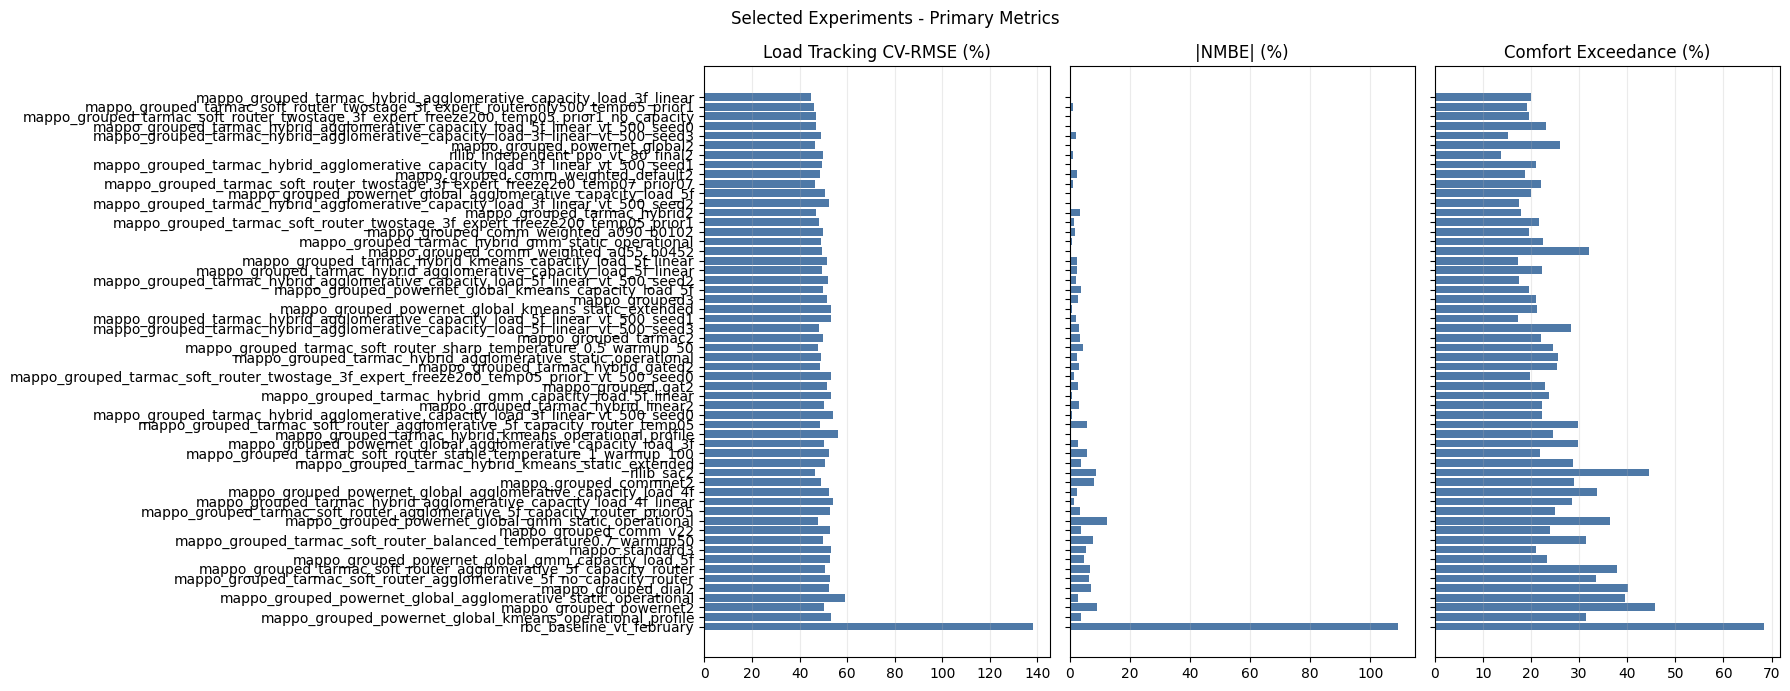

In [8]:
plot_df = primary_only_df.sort_values('primary_rank').copy()
labels = plot_df['experiment'].str.replace('_vt_500_final', '', regex=False)
labels = labels.str.replace('_vt_42_final', '', regex=False)
labels = labels.str.replace('_vt_50_final', '', regex=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

metrics = [
    ('primary_load_cv_rmse_pct', 'Load Tracking CV-RMSE (%)'),
    ('primary_abs_nmbe_pct', '|NMBE| (%)'),
    ('primary_comfort_exceedance_pct', 'Comfort Exceedance (%)'),
]

for ax, (column, title) in zip(axes, metrics):
    ax.barh(labels, plot_df[column], color='#4e79a7')
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)

fig.suptitle('Selected Experiments - Primary Metrics')
fig.tight_layout()

plot_path = OUTPUT_ROOT / 'selected_experiment_primary_metrics.png'
fig.savefig(plot_path, dpi=180, bbox_inches='tight')
print(f'Plot -> {plot_path}')
plt.show()


## Secondary Metrics Plots

Plot -> C:\Users\16199\Desktop\RL\annex96_common_exercise_1\experiment_metric_summary\selected_experiment_secondary_metrics.png


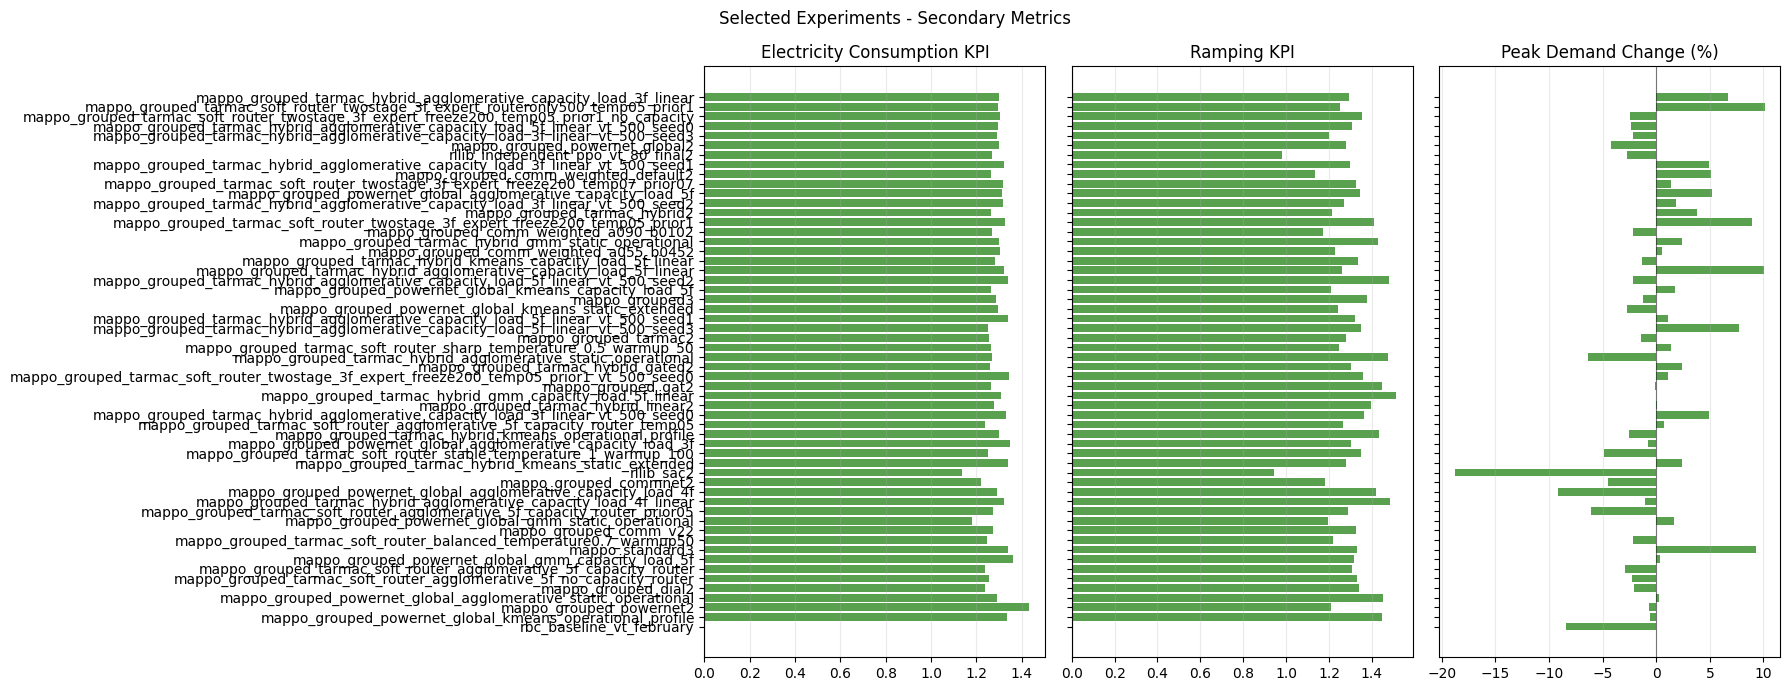

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

secondary_metrics = [
    ('kpi_electricity_consumption', 'Electricity Consumption KPI'),
    ('kpi_ramping', 'Ramping KPI'),
    ('secondary_peak_demand_change_pct', 'Peak Demand Change (%)'),
]

for ax, (column, title) in zip(axes, secondary_metrics):
    ax.barh(labels, plot_df[column], color='#59a14f')
    ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(axis='x', alpha=0.25)

fig.suptitle('Selected Experiments - Secondary Metrics')
fig.tight_layout()

plot_path = OUTPUT_ROOT / 'selected_experiment_secondary_metrics.png'
fig.savefig(plot_path, dpi=180, bbox_inches='tight')
print(f'Plot -> {plot_path}')
plt.show()


## W&B Match Check

In [10]:
wandb_check_columns = ['experiment', 'wandb_run_id', 'wandb_started_at', 'wandb_program', 'wandb_run_dir']
display(df[[column for column in wandb_check_columns if column in df.columns]])


,experiment,wandb_run_id,wandb_started_at,wandb_program,wandb_run_dir
0,rllib_independent_ppo_vt_80_final2,ymjhdsaz,2026-04-24T06:16:20.110858Z,-m rllib_independent_ppo.train,wandb/run-20260424_141620-ymjhdsaz
1,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed3,NaN,NaN,NaN,NaN
2,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_5f_linear_vt_500_seed0,NaN,NaN,NaN,NaN
3,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp05_prior1_no_capacity_vt_500_final,NaN,NaN,NaN,NaN
4,mappo_grouped_powernet_global_vt_500_final2,29aaxpgi,2026-04-24T06:16:27.155931Z,-m mappo_grouped_powernet_global.train,wandb/run-20260424_141627-29aaxpgi
5,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_final,NaN,NaN,NaN,NaN
6,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_final,NaN,NaN,NaN,NaN
7,mappo_grouped_comm_weighted_default_vt_500_final2,i8t6aug2,2026-04-24T06:16:26.466647Z,-m mappo_grouped_comm_weighted.train,wandb/run-20260424_141626-i8t6aug2
8,mappo_grouped_comm_weighted_a090_b010_vt_500_final2,p583uys0,2026-04-24T06:16:32.389601Z,-m mappo_grouped_comm_weighted.train,wandb/run-20260424_141632-p583uys0
9,mappo_grouped_tarmac_hybrid_vt_500_final2,NaN,NaN,NaN,NaN
